In [36]:
import pandas as pd

In [37]:
# Reading csv to Data Frame
df = pd.read_csv('../data/Cleaned-Superstore.csv')

# Exploratory Data Analysis
# 1. Sales by Category
df.describe(include='str')

sales_by_category_series = df.groupby('Category')['Sales'].sum()
print(sales_by_category_series)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [38]:
# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

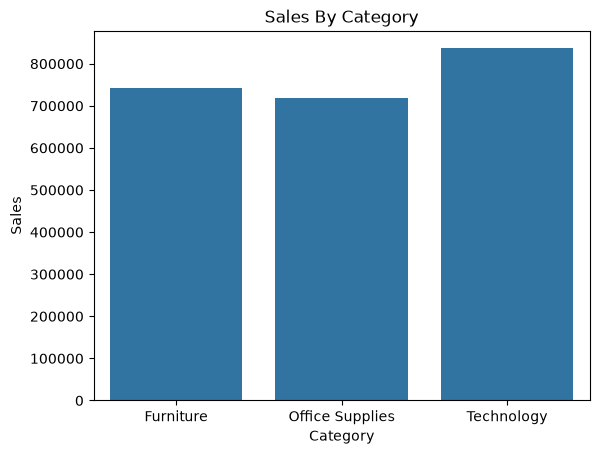

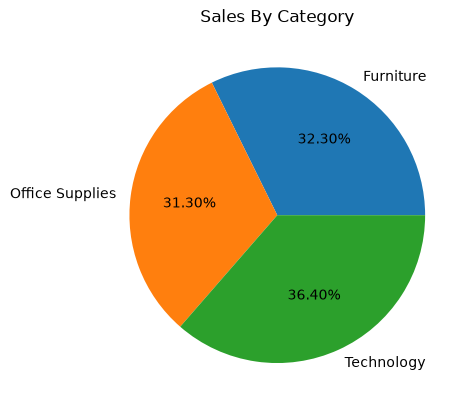

In [39]:
# Visualizing sales_by_category using bar plot 
sns.barplot(x='Category', y='Sales', data=sales_by_category_series.to_frame())
plt.title("Sales By Category")
plt.show()
# Visualizing sales_by_category using pie chart 
plt.figure()
df.groupby('Category')['Sales'].sum().plot(kind='pie', autopct="%1.2f%%")
plt.title("Sales By Category")
plt.show()

In [40]:
# 2. Sales by Region
sales_by_region_series = df.groupby('Region')['Sales'].sum()
print(sales_by_region_series)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


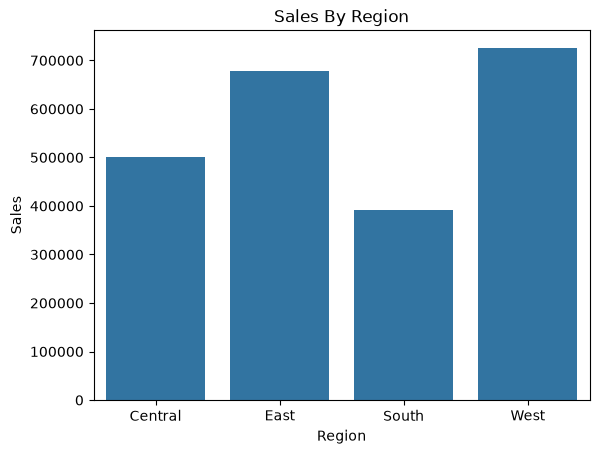

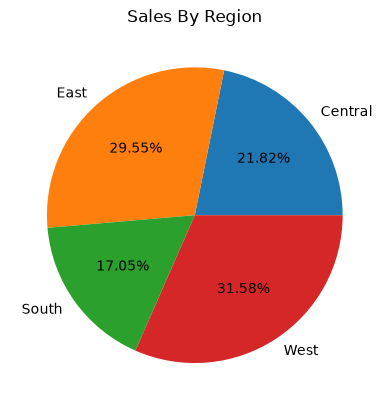

In [41]:
# Visualizing sales_by_region using bar plot 
plt.figure()
sns.barplot(x='Region', y='Sales', data=sales_by_region_series.to_frame())
plt.title("Sales By Region")
# Visualizing sales_by_region using pie chart 
plt.figure()
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct="%1.2f%%")
plt.title("Sales By Region")
plt.show()

In [42]:
# 3. Monthly Sales Trend

# 3.1 Seasonability Trend
monthly_trend_series = df.groupby('Order Month')['Sales'].sum()
print(monthly_trend_series)
   

Order Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


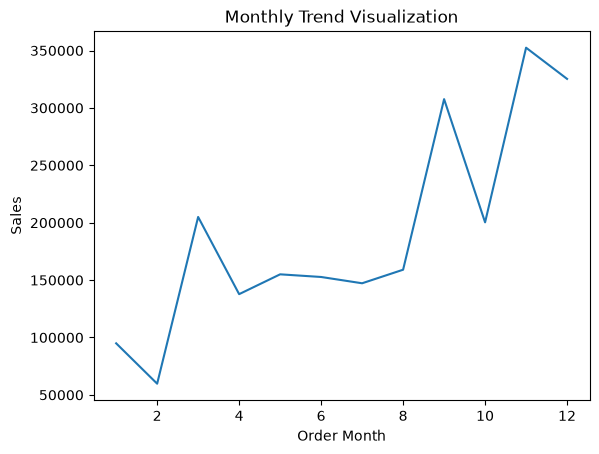

In [43]:
# Visualizing monthly_trend using line chart
sns.lineplot(x='Order Month', y='Sales', data=monthly_trend_series.to_frame())
plt.title("Monthly Trend Visualization")
plt.show()

In [44]:
#3.2 Full timeline trend
full_timeline_trend_series = df.groupby(['Order Year', 'Order Month'])['Sales'].sum()
print(full_timeline_trend_series)

Order Year  Order Month
2014        1               14236.8950
            2                4519.8920
            3               55691.0090
            4               28295.3450
            5               23648.2870
            6               34595.1276
            7               33946.3930
            8               27909.4685
            9               81777.3508
            10              31453.3930
            11              78628.7167
            12              69545.6205
2015        1               18174.0756
            2               11951.4110
            3               38726.2520
            4               34195.2085
            5               30131.6865
            6               24797.2920
            7               28765.3250
            8               36898.3322
            9               64595.9180
            10              31404.9235
            11              75972.5635
            12              74919.5212
2016        1               18542.4910
 

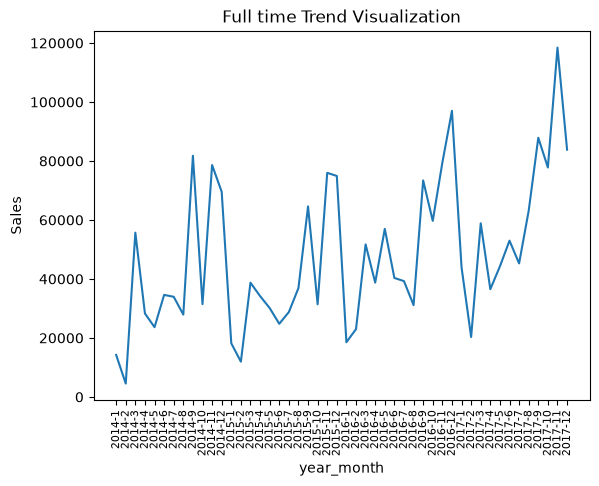

In [45]:
# Visualizing full_timeline_trend using line chart
full_timeline_trend_dataframe = full_timeline_trend_series.reset_index()
full_timeline_trend_dataframe['year_month'] = full_timeline_trend_dataframe['Order Year'].astype(str) + '-' + full_timeline_trend_dataframe['Order Month'].astype(str)

# year_month_series = full_timeline_trend_dataframe['Order Year'].astype(str) + full_timeline_trend_dataframe['Order Month'].astype(str)
sns.lineplot(x='year_month', y='Sales', data=full_timeline_trend_dataframe)
plt.title("Full time Trend Visualization")
# without rotation and fontsize it get overlaps
plt.xticks(rotation=90, fontsize=8)
plt.show()

In [46]:
# 4. Profit Analysis 
profit_analysis_series = df.groupby('Order Year')['Profit'].sum()
print(profit_analysis_series)

Order Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64


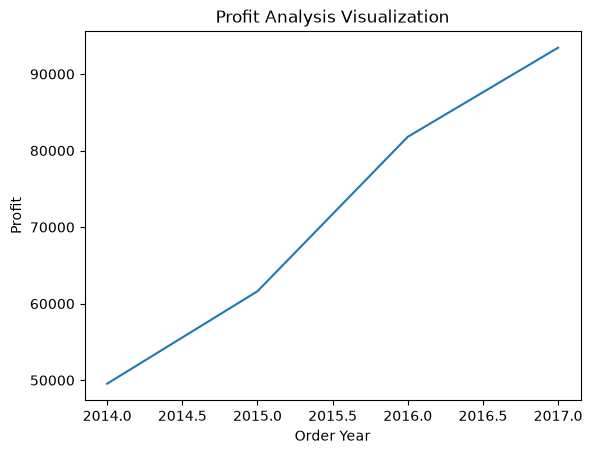

In [56]:
# Visualizing profit_analysis using line chart
sns.lineplot(x='Order Year', y='Profit', data=profit_analysis_series.to_frame())
plt.title('Profit Analysis Visualization')
plt.show()

In [48]:
# 5.Top Products
top_products = df.groupby('Product Name')['Profit'].sum().reset_index()
top_10_products = top_products.sort_values(by='Profit', ascending=False).head(15)
print(top_10_products)

                                           Product Name      Profit
404               Canon imageCLASS 2200 Advanced Copier  25199.9280
650   Fellowes PB500 Electric Punch Plastic Comb Bin...   7753.0390
805                Hewlett Packard LaserJet 3310 Copier   6983.8836
400                  Canon PC1060 Personal Laser Copier   4570.9347
787   HP Designjet T520 Inkjet Large Format Printer ...   4094.9766
165                   Ativa V4110MDD Micro-Cut Shredder   3772.9461
19     3D Systems Cube Printer, 2nd Generation, Magenta   3717.9714
1276  Plantronics Savi W720 Multi-Device Wireless He...   3696.2820
895                Ibico EPK-21 Electric Binding System   3345.2823
1840                  Zebra ZM400 Thermal Label Printer   3343.5360
859   Honeywell Enviracaire Portable HEPA Air Cleane...   3247.0200
804   Hewlett Packard 610 Color Digital Copier / Pri...   3124.9375
1269  Plantronics CS510 - Over-the-Head monaural Wir...   3085.0325
398                  Canon Imageclass D680 Copie

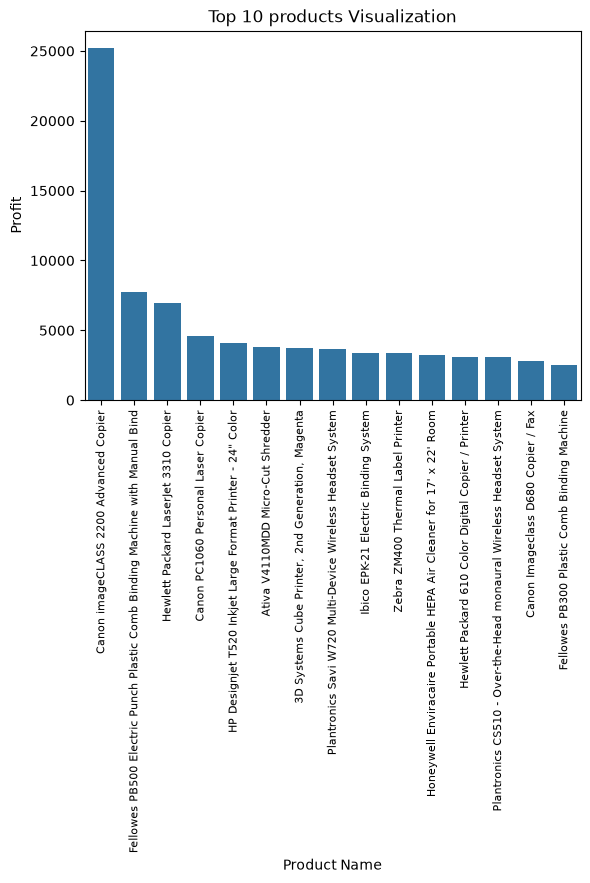

In [49]:
# Visualizing Top_10_products using bar chart
sns.barplot(x='Product Name', y='Profit', data=top_10_products)
plt.title('Top 10 products Visualization')
plt.xticks(rotation=90, fontsize=8)
plt.show()

In [50]:
# 6. Customer Analysis
top_sales_per_customer = df.groupby('Customer Name')['Sales'].sum().reset_index()
top_sales_per_customer = top_sales_per_customer.sort_values(ascending=False, by='Sales').head(15)
print(top_sales_per_customer)

          Customer Name      Sales
686         Sean Miller  25043.050
730        Tamara Chand  19052.218
622        Raymond Buch  15117.339
757        Tom Ashbrook  14595.620
6         Adrian Barton  14473.571
441        Ken Lonsdale  14175.229
671        Sanjit Chand  14142.334
334        Hunter Lopez  12873.298
672        Sanjit Engle  12209.438
156  Christopher Conant  12129.072
756        Todd Sumrall  11891.751
312           Greg Tran  11820.120
75         Becky Martin  11789.630
689         Seth Vernon  11470.950
132     Caroline Jumper  11164.974


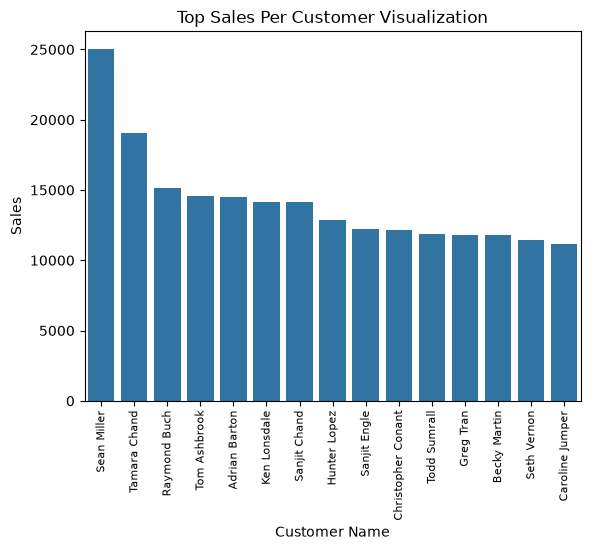

In [51]:
# Visualizing Total_sales_per_customer using bar chart
sns.barplot(x='Customer Name', y='Sales', data=top_sales_per_customer)
plt.title('Top Sales Per Customer Visualization')
plt.xticks(rotation=90, fontsize=8)
plt.show()

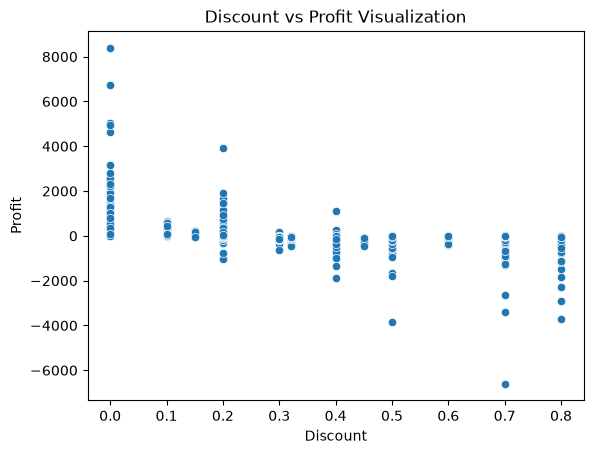

In [52]:
# 7. Discount vs Profit
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit Visualization")
plt.show()

In [53]:
# 8.Shipping Analysis 
ship_mode_counts = df['Ship Mode'].value_counts()
print(ship_mode_counts)

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


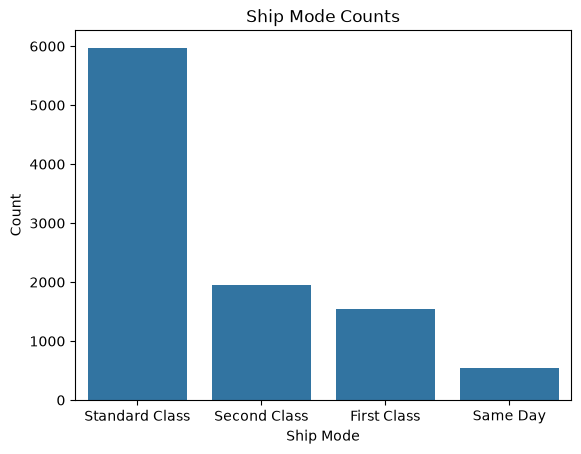

In [54]:
ship_mode_counts_df = ship_mode_counts.reset_index()
# Changing the column name (reset_index stores Ship Mode and count. so count --> Count)
ship_mode_counts_df.columns = ['Ship Mode', 'Count']
sns.barplot(x='Ship Mode', y='Count', data=ship_mode_counts_df)
plt.title("Ship Mode Counts")
plt.show()

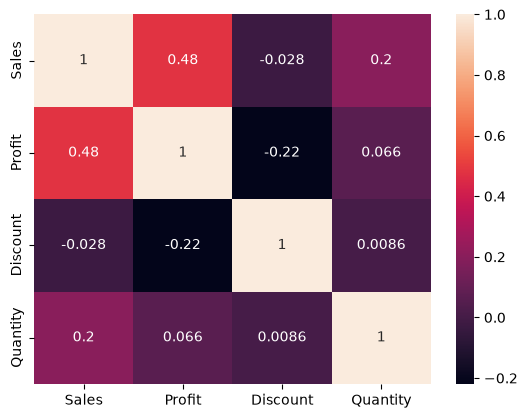

In [55]:
# Final HeatMap that correlates major numerical relationships
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True)
plt.show()